In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
from arch import arch_model

from config import RAW_DATA_DIR
from core.models import (IIDNormalModel, IIDStudentTModel, IIDNonNormalModel, AR1NormalModel,
        AR1NonNormalModel, GARCH11Model, AR1GARCH11NormalModel, AR1GARCH11SymmModel)
from core.hierarchical_model_sel import hierarchical_analysis

In [ ]:
prices = pd.read_csv(
    RAW_DATA_DIR / "SPDR_WE.csv",
    parse_dates=["Date"], index_col="Date"
)
prices = prices.loc[:, ~prices.columns.str.contains("^Unnamed")]

prices = prices.sort_index()
prices.describe()

,XLK,XLF,XLV,XLE,XLY,XLP,XLRE,SPTL,GLD,SPIP
count,523.000000,523.000000,523.000000,523.000000,523.000000,523.000000,523.000000,523.000000,523.000000,523.000000
mean,63.567380,32.518317,110.451912,34.549465,71.749082,65.596424,37.395010,34.975124,25.983824,27.885258
std,33.731731,9.482523,27.215558,8.319281,22.949211,10.417656,5.038957,6.147291,12.663092,1.874107
min,19.640000,16.640000,63.950000,12.930000,34.900000,48.300000,27.160000,24.670000,8.200000,24.420000
25%,34.025000,25.375000,85.380000,29.300000,52.555000,55.010000,32.925000,29.105000,16.980000,26.095000
50%,61.870000,30.770000,113.000000,33.990000,71.490000,66.150000,37.050000,34.930000,19.900000,27.920000
75%,84.215000,38.050000,133.815000,42.325000,89.050000,74.830000,41.040000,39.535000,32.120000,28.880000
max,150.340000,55.620000,157.650000,49.040000,122.050000,83.930000,51.810000,48.860000,58.230000,31.810000


<Axes: xlabel='Date'>

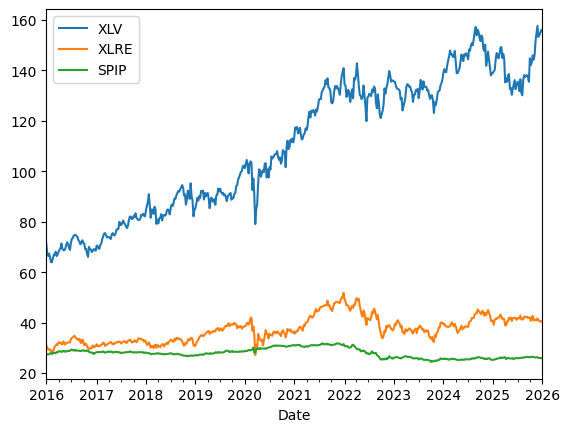

In [ ]:
prices[["XLV", "XLRE", "SPIP"]].plot()

In [ ]:
rets = prices.pct_change()
print(rets.head())

                 XLK       XLF       XLV       XLE       XLY       XLP  \
Date                                                                     
2016-01-01       NaN       NaN       NaN       NaN       NaN       NaN   
2016-01-08 -0.063959 -0.072351 -0.055618 -0.070697 -0.058086 -0.029115   
2016-01-15 -0.018953 -0.031198 -0.016869 -0.030136 -0.028797 -0.014688   
2016-01-22  0.026436 -0.006325  0.014600  0.025388  0.025455  0.020497   
2016-01-29  0.021298  0.020833 -0.020323  0.044346  0.010911  0.029823   

                XLRE      SPTL       GLD      SPIP  
Date                                                
2016-01-01       NaN       NaN       NaN       NaN  
2016-01-08 -0.034317  0.021465 -0.004084  0.006589  
2016-01-15 -0.028562  0.018773 -0.048037 -0.001091  
2016-01-22  0.007863 -0.003025  0.134769 -0.002184  
2016-01-29 -0.009837  0.014345 -0.147505  0.014593  
XLK     float64
XLF     float64
XLV     float64
XLE     float64
XLY     float64
XLP     float64
XLRE    float6

<Axes: xlabel='Date'>

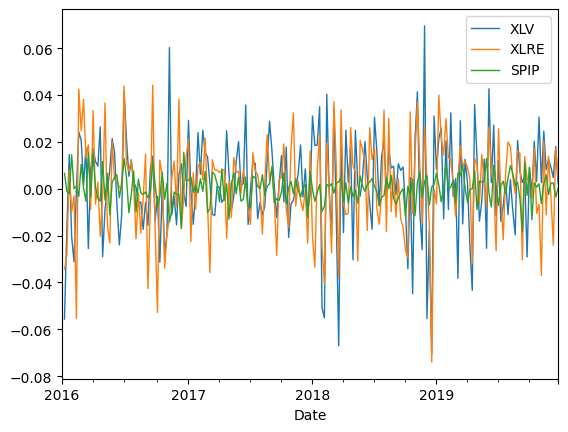

In [ ]:
rets.loc["2016":"2019", ["XLV", "XLRE", "SPIP"]].plot(linewidth=1)


In [12]:
cols = ["XLV", "XLRE", "SPIP"]
dgps = [(column, rets[column].dropna().values) for column in cols]

In [13]:
rows = []
for name, dgp in dgps:
    res = hierarchical_analysis(dgp, name=name)
    #res["true_spec"] = expected[name]
    #res["match"]     = res["final_spec"] == expected[name]
    rows.append(res)

df = pd.DataFrame(rows)

# show transposed for readability (one column per series)
print("\n=== Hierarchical diagnostics (one column per series) ===\n")
print(df.set_index("series").T.to_string())
print("\n=== Summary ===\n")
print(df[["series", "final_spec"]].to_string(index=False))


=== Hierarchical diagnostics (one column per series) ===

series                                XLV                         XLRE                         SPIP
S1_LB_ret_p                        0.0131                       0.0087                       0.0096
S1_AR?                               True                         True                         True
S2_ARCH_LM_p                          0.0                          0.0                          0.0
S2_GARCH?                            True                         True                         True
S3_JB_p                               0.0                          0.0                          0.0
S3_skew_p                          0.0001                          0.0                          0.0
S3_skewness                        -0.446                       -0.489                       -0.538
S3_exkurt                           1.509                        1.496                        2.406
S3_innov                           Skew-t

In [19]:
models = []
for model_desc in df['final_spec']:
    if 'Const' in model_desc:
        models.append(GARCH11Model())
    elif 'AR(1)' in model_desc:
        if 'Normal' in model_desc:
            models.append(AR1GARCH11NormalModel())
        elif 'Student-t' in model_desc:
            models.append(AR1GARCH11SymmModel())
        elif 'Skew-t' in model_desc:
            models.append(AR1GARCH11SymmModel())
        else:
            print(f"unknown {model_desc}")
    else:
        print(f"unknown {model_desc}")
        
models

[AR1GARCH11SymmModel(), AR1GARCH11SymmModel(), AR1GARCH11SymmModel()]

In [16]:
def get_PSR(series, model, params, sr_null = 0.0):
    sr_h = series.mean() / series.std(ddof=1)
    avar = model.avar(sr_h, **params)
    psr = norm.cdf((sr_h-sr_null)/np.sqrt(avar/len(series)))
    return psr

In [ ]:
model_classes = [
    IIDNormalModel, 
    AR1NonNormalModel, 
    GARCH11Model, 
    AR1GARCH11SymmModel
]

sr_null = 0.00

for name, series in dgps:
    for model_cls in model_classes:
        model = model_cls()
        params = model.fit(series)
        psr = get_PSR(series, model, params, sr_null=sr_null)
        print(f"{name:<10} {model.short_name:<18} {psr*100:10.4f}%")

XLV        iid_normal            95.7996%
XLV        ar1_nonnormal         96.9516%
XLV        garch11               94.9353%
XLV        ar1_garch11symm       96.4409%
XLRE       iid_normal            76.5149%
XLRE       ar1_nonnormal         79.8892%
XLRE       garch11               76.1354%
XLRE       ar1_garch11symm       78.5587%
SPIP       iid_normal            42.8805%
SPIP       ar1_nonnormal         42.1993%
SPIP       garch11               42.7957%
SPIP       ar1_garch11symm       42.2199%
